In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualizaciones
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("=" * 80)
print("CHURN PREDICTION - EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 80)

CHURN PREDICTION - EXPLORATORY DATA ANALYSIS (EDA)


In [3]:
# Cargar dataset
df = pd.read_csv('../data/raw/Churn_Modelling.csv')

print("\n1. DIMENSIONES DEL DATASET")
print(f"Registros: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print(f"Shape: {df.shape}")


1. DIMENSIONES DEL DATASET
Registros: 10000
Columnas: 14
Shape: (10000, 14)


In [4]:
print("\n2. PRIMERAS 5 FILAS")
print(df.head())


2. PRIMERAS 5 FILAS
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63   

In [5]:
print("\n3. INFORMACIÓN DEL DATASET")
print(df.info())


3. INFORMACIÓN DEL DATASET
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB
None


In [6]:
print("\n4. ESTADÍSTICAS DESCRIPTIVAS")
print(df.describe())


4. ESTADÍSTICAS DESCRIPTIVAS
         RowNumber    CustomerId   CreditScore           Age        Tenure  \
count  10000.00000  1.000000e+04  10000.000000  10000.000000  10000.000000   
mean    5000.50000  1.569094e+07    650.528800     38.921800      5.012800   
std     2886.89568  7.193619e+04     96.653299     10.487806      2.892174   
min        1.00000  1.556570e+07    350.000000     18.000000      0.000000   
25%     2500.75000  1.562853e+07    584.000000     32.000000      3.000000   
50%     5000.50000  1.569074e+07    652.000000     37.000000      5.000000   
75%     7500.25000  1.575323e+07    718.000000     44.000000      7.000000   
max    10000.00000  1.581569e+07    850.000000     92.000000     10.000000   

             Balance  NumOfProducts    HasCrCard  IsActiveMember  \
count   10000.000000   10000.000000  10000.00000    10000.000000   
mean    76485.889288       1.530200      0.70550        0.515100   
std     62397.405202       0.581654      0.45584        0.49979

In [7]:
print("\n5. MISSING VALUES")
missing = df.isnull().sum()
print(missing[missing > 0])
if missing.sum() == 0:
    print("✅ No hay valores faltantes")


5. MISSING VALUES
Series([], dtype: int64)
✅ No hay valores faltantes


In [8]:
print("\n6. ANÁLISIS DE CHURN")
print(f"\nTotal de clientes: {len(df)}")
print(f"Clientes que se fueron (Churn=1): {df['Exited'].sum()}")
print(f"Clientes que se quedaron (Churn=0): {(df['Exited'] == 0).sum()}")

churn_rate = (df['Exited'].sum() / len(df)) * 100
print(f"\n📊 TASA DE CHURN: {churn_rate:.2f}%")

print("\nDistribución:")
print(df['Exited'].value_counts())
print("\nPorcentajes:")
print(df['Exited'].value_counts(normalize=True) * 100)


6. ANÁLISIS DE CHURN

Total de clientes: 10000
Clientes que se fueron (Churn=1): 2037
Clientes que se quedaron (Churn=0): 7963

📊 TASA DE CHURN: 20.37%

Distribución:
Exited
0    7963
1    2037
Name: count, dtype: int64

Porcentajes:
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


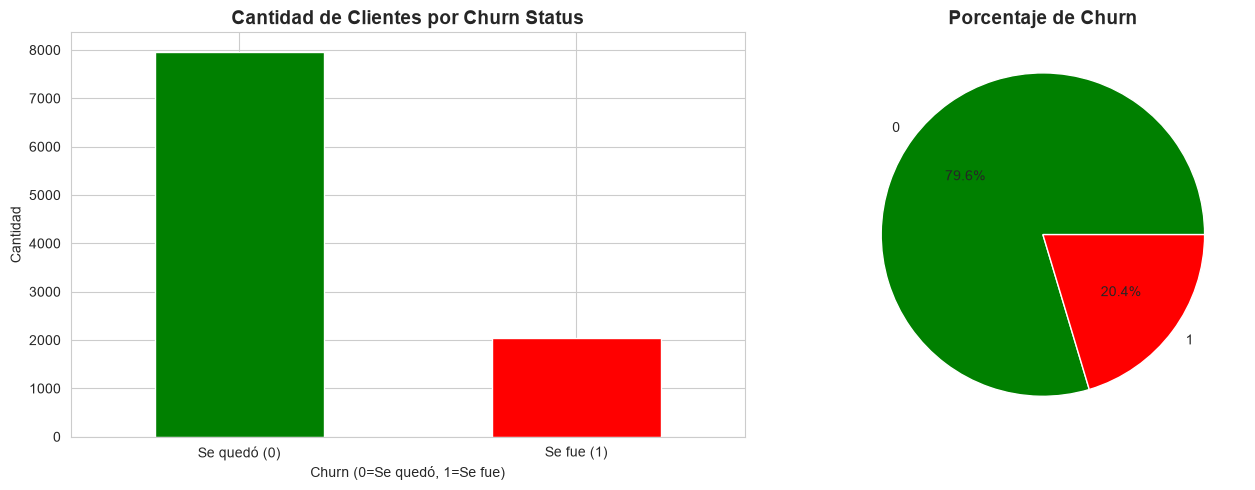

✅ Visualización completada


In [9]:
# Gráfico de churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Conteo
df['Exited'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Cantidad de Clientes por Churn Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn (0=Se quedó, 1=Se fue)')
axes[0].set_ylabel('Cantidad')
axes[0].set_xticklabels(['Se quedó (0)', 'Se fue (1)'], rotation=0)

# Gráfico 2: Porcentaje
df['Exited'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                  colors=['green', 'red'])
axes[1].set_title('Porcentaje de Churn', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("✅ Visualización completada")

In [10]:
print("\n7. COLUMNAS DEL DATASET")
print("\nNombre de las columnas:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

print(f"\nTipos de datos:")
print(df.dtypes)


7. COLUMNAS DEL DATASET

Nombre de las columnas:
 1. RowNumber
 2. CustomerId
 3. Surname
 4. CreditScore
 5. Geography
 6. Gender
 7. Age
 8. Tenure
 9. Balance
10. NumOfProducts
11. HasCrCard
12. IsActiveMember
13. EstimatedSalary
14. Exited

Tipos de datos:
RowNumber            int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


In [17]:
print("\n8. CORRELACIÓN CON CHURN")
correlation = df.corr(numeric_only=True)['Exited'].sort_values(ascending=False)
print(correlation)


8. CORRELACIÓN CON CHURN
Exited             1.000000
Age                0.285323
Balance            0.118533
EstimatedSalary    0.012097
CustomerId        -0.006248
HasCrCard         -0.007138
Tenure            -0.014001
RowNumber         -0.016571
CreditScore       -0.027094
NumOfProducts     -0.047820
IsActiveMember    -0.156128
Name: Exited, dtype: float64


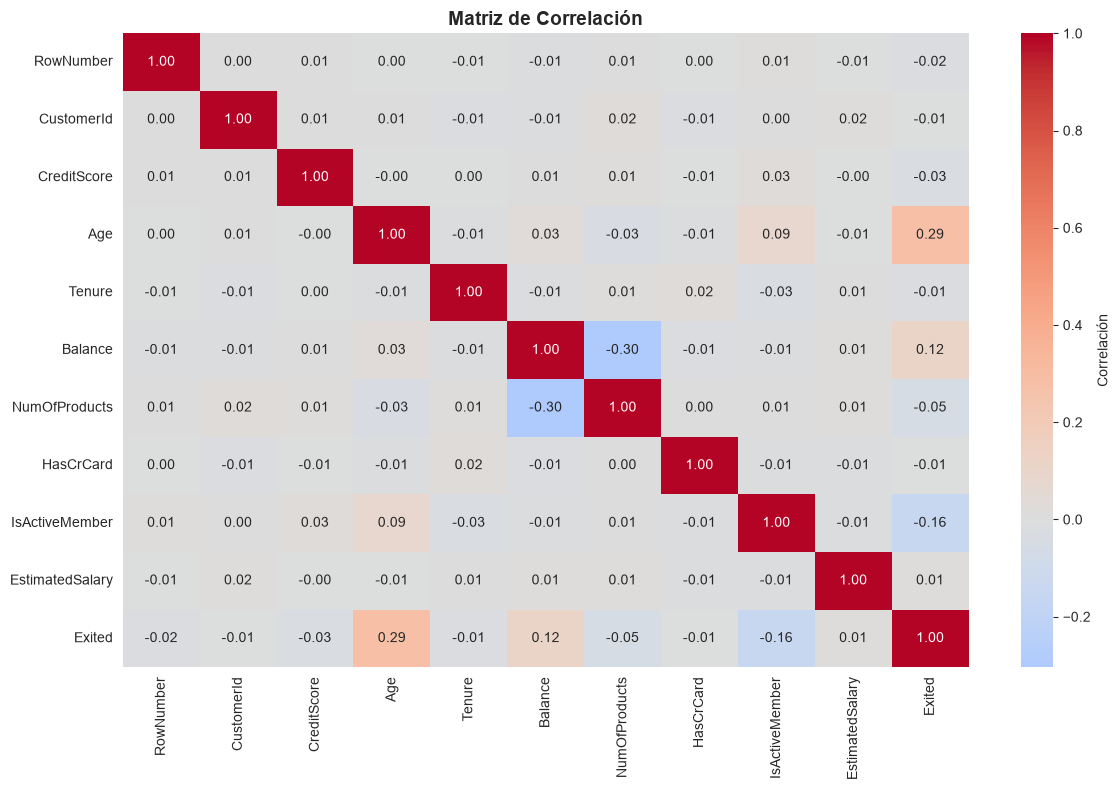

In [20]:
# Heatmap de correlación (solo numéricas)
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', center=0, fmt='.2f', cbar_kws={'label': 'Correlación'})
plt.title('Matriz de Correlación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()